# I put the cells together to make it load all at once for time saving

In [ ]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import math
import time

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['like', 'stop']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

PATH = "gesture_dataset_sample"
# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

annotations = dict()

for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f"{PATH}/{condition}")):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label == "no_gesture":
                continue
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

X_train = np.array(X_train).astype('float32')
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.

y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

  0%|          | 0/251 [00:00<?, ?it/s]

''


  0%|          | 0/250 [00:00<?, ?it/s]

(400, 64, 64, 3) (100, 64, 64, 3) (400, 2) (100, 2)


# -----------------Start of Task---------------------
# Expectations

I expected the accuracy and validation-accuracy to rise with each layer and reach a plateu.  
I also expected one layer to have much lower accuracys.  
What i didn't anticipate is the influence of Pooling.  

My Approach was to just leave everything as is and put the creation of the model into a function where i can define the number of layers.  
#The only other thing i changed was augmenting the train/test-split to shuffle and stratify to get better data.  
In the function itself there is a for-loop with the number of layers as range.  
As a result i compared the loss, accuracy, val-accuracy, needed epochs and the difference between accuracies and put them into fitting plots.   
Additionally i plotted the history of every model and the corresponding confusion-matrix

INFO:
Training takes approximatly **90-120 seconds**

In [21]:
# variables for hyperparameters
batch_size = 8
epochs = 50
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'  # LeakyReLU
layer_count = 2
num_neurons = 64

def create_model(num_conv_layers):
    model = Sequential(name=f"Model-{num_conv_layers}-Layers")
    #model.add(RandomFlip('horizontal'))
    #model.add(RandomContrast(0.1))
    
    model.add(Input(shape=(SIZE[0], SIZE[1], COLOR_CHANNELS)))
    #model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, padding='same'))
    #model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

    #Number of layers
    for i in range(num_conv_layers):
        model.add(Conv2D(32,(3, 3),activation=activation_conv,padding="same"))
        model.add(MaxPooling2D((2,2), padding="same"))

    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(num_neurons,activation=activation))
    model.add(Dense(num_classes,activation="softmax"))
    
    # specify loss function, optimizer and evaluation metrics
    # for classification, categorial crossentropy is used as a loss function
    # use the adam optimizer unless you have a good reason not to
    model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

    return model

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs


In [22]:
conv_layer_counts = [0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 16]

val_accs = []
train_accs = []
val_losses = []
train_losses = []

epochs_used = []
conf_matrices = []
histories = []
models = []

starttime = time.time()
for layers in conv_layer_counts:
    print(f"--------------------------\nTRAINING WITH {layers} LAYERS:\n")
    model = create_model(layers)

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
    stop_early = EarlyStopping(monitor='val_loss', patience=3)
    
    history = model.fit(
        X_train,
        train_label,
        batch_size=batch_size,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, test_label),
        callbacks=[reduce_lr, stop_early]
    )
    #accuracy = history.history['accuracy'][-1]
    #val_accuracy = history.history['val_accuracy'][-1]
    #train_loss.append(history.history['loss'][-1])
    #val_loss.append(history.history['val_loss'][-1])

    best_run = np.argmin(history.history['val_loss'])
    
    accuracy = history.history['accuracy'][best_run]
    val_accuracy = history.history['val_accuracy'][best_run]
    train_loss = history.history['loss'][best_run]
    val_loss = history.history['val_loss'][best_run]
    epochs_needed = len(history.history['accuracy'])
    
    epochs_used.append(epochs_needed)
    train_accs.append(accuracy)
    val_accs.append(val_accuracy)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    models.append(model)
    histories.append(history)

    y_predictions = model.predict(X_test)
    y_predictions = np.argmax(y_predictions, axis=1)
    conf_matrix = confusion_matrix(y_test, y_predictions)
    conf_matrices.append(conf_matrix)
    #if not os.path.exists("models/layer-experiment"):
    #    os.mkdir("models/layer-experiment")
    #model.save(f"models/layer-experiment/layer_presentation_model_layers_{num_conv_layers}.keras")

tookTime = time.time() - starttime
print(f"Fitting took {tookTime:.0f} seconds")

--------------------------
TRAINING WITH 0 LAYERS:

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6275 - loss: 1.4525 - val_accuracy: 0.5500 - val_loss: 0.6669 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5725 - loss: 0.6823 - val_accuracy: 0.6100 - val_loss: 0.6572 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6200 - loss: 0.6584 - val_accuracy: 0.5900 - val_loss: 0.6473 - learning_rate: 0.0010
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6600 - loss: 0.6301 - val_accuracy: 0.6000 - val_loss: 0.6323 - learning_rate: 0.0010
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6875 - loss: 0.6146 - val_accuracy: 0.6300 - val_loss: 0.6176 - learning_rate: 0.0010
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7025 - loss: 0.5824 - val_accuracy: 0.6700 - val_loss: 0.6043 - learning_rate: 0.0010
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

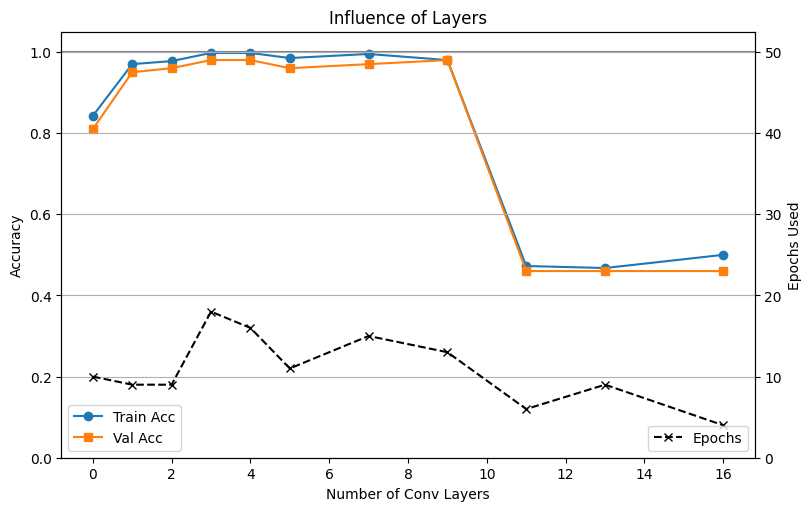

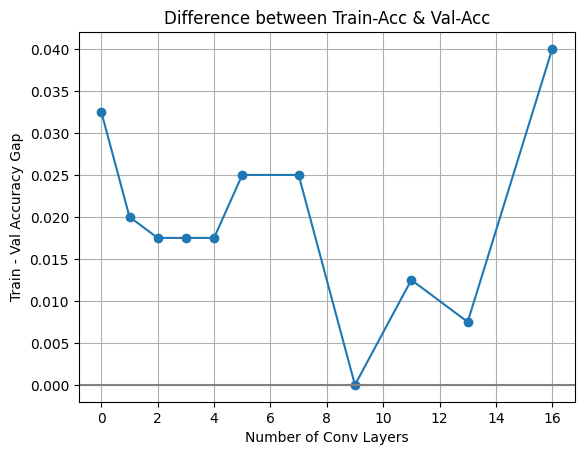

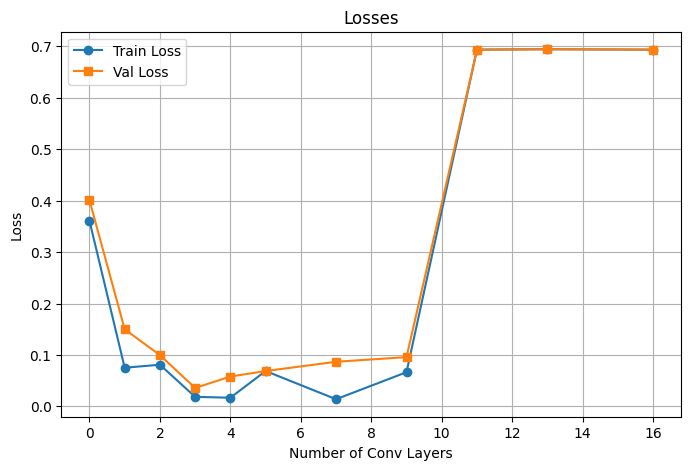

In [141]:
#Accuracy and epochs
fig, ax1 = plt.subplots(figsize=(8,5),constrained_layout=True)

ax1.plot(conv_layer_counts, train_accs, marker="o", label="Train Acc")
ax1.plot(conv_layer_counts, val_accs, marker="s", label="Val Acc")
ax1.set_xlabel("Number of Conv Layers")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.05)
ax1.legend(loc="lower left")
ax1.axhline(1, color='gray')

ax2 = ax1.twinx()
ax2.plot(conv_layer_counts, epochs_used, marker="x", linestyle="--", color="black", label="Epochs")
ax2.set_ylabel("Epochs Used")
ax2.set_ylim(0,52.5)
ax2.legend(loc="lower right")

plt.xlabel("Nmbr of Conv-Layer")
plt.title("Influence of Layers")
plt.grid(True)
plt.show()

#Difference in Accuracy
difference = np.array(train_accs) - np.array(val_accs)
plt.plot(conv_layer_counts, difference, marker="o")
plt.xlabel("Number of Conv Layers")
plt.ylabel("Train - Val Accuracy Gap")
plt.title("Difference between Train-Acc & Val-Acc")
plt.axhline(0, color='gray')
plt.grid(True)
plt.show()

#Loss
fig1, axel = plt.subplots(figsize=(8,5))
axel.plot(conv_layer_counts, train_losses, marker="o", label="Train Loss")
axel.plot(conv_layer_counts, val_losses, marker="s", label="Val Loss")

axel.set_xlabel("Number of Conv Layers")
axel.set_ylabel("Loss")
axel.set_title("Losses")
axel.legend()
axel.grid(True)

plt.show()




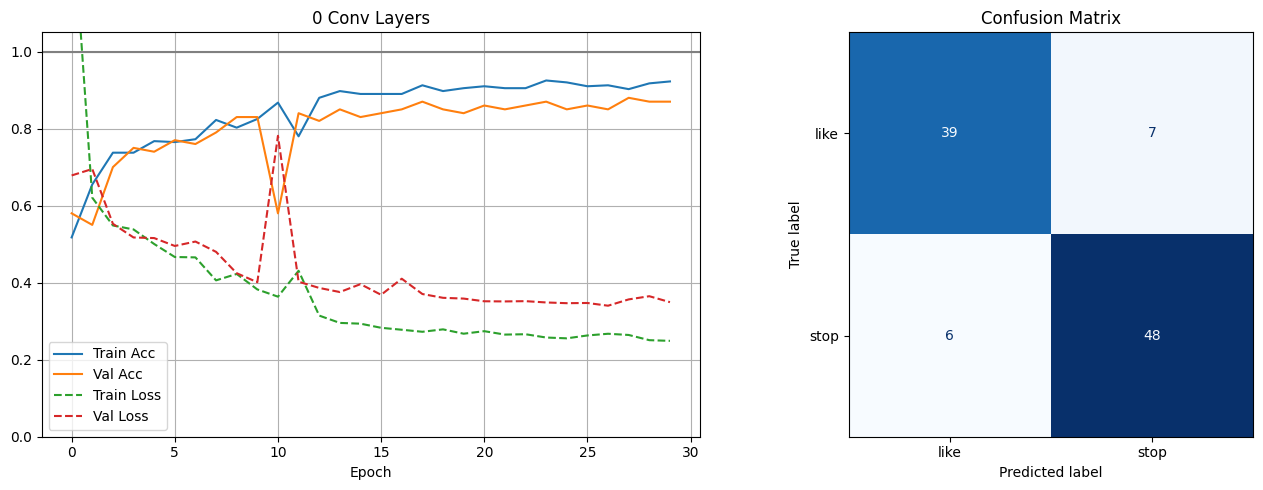

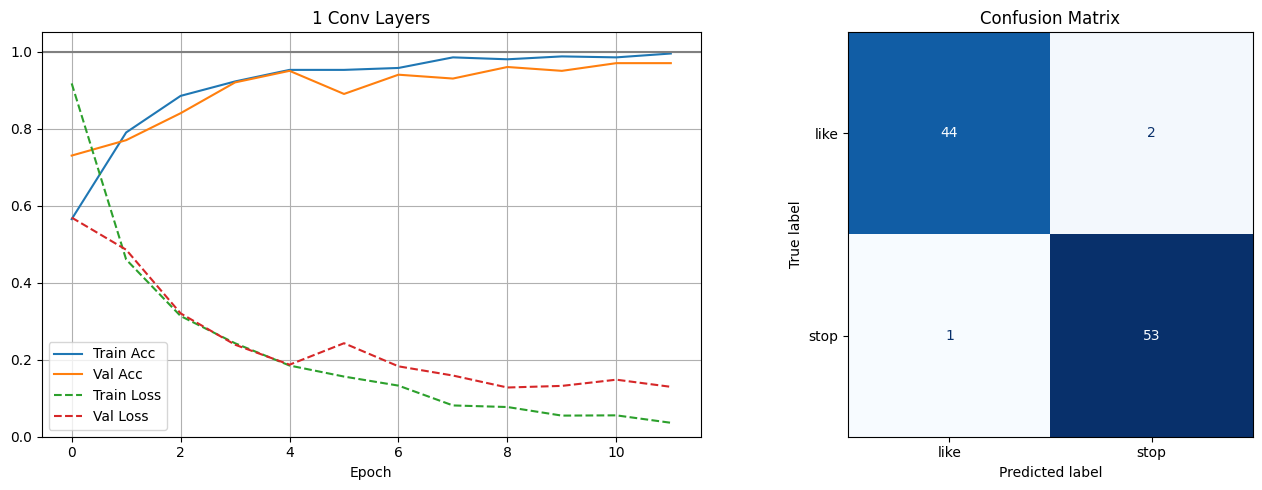

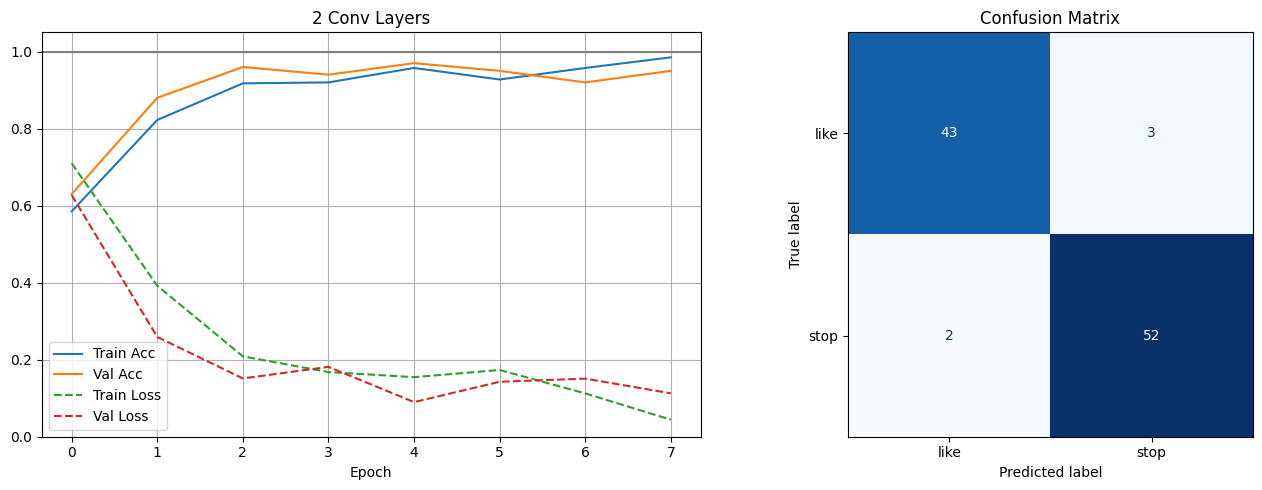

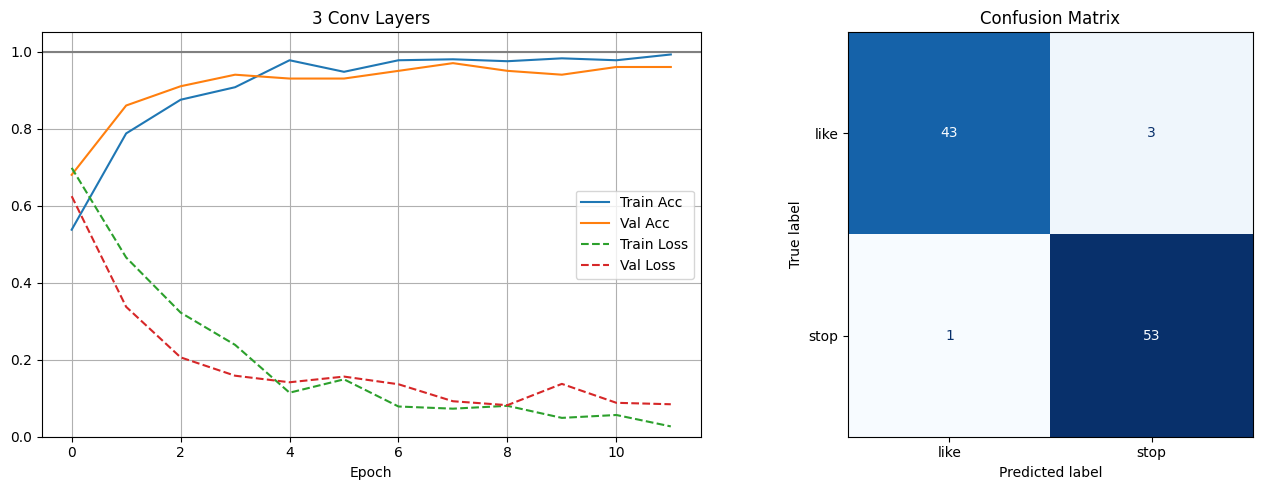

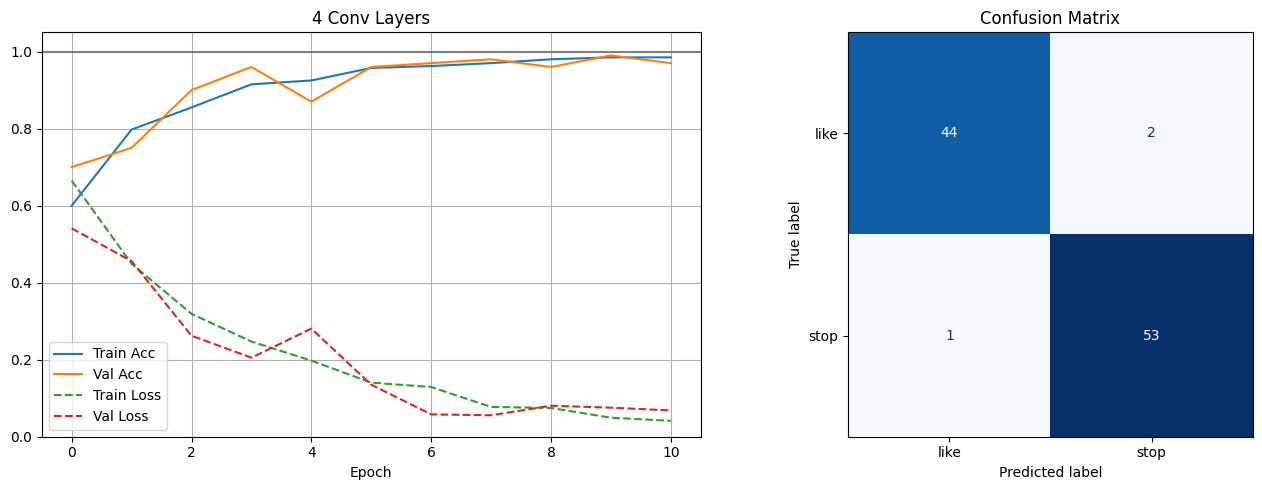

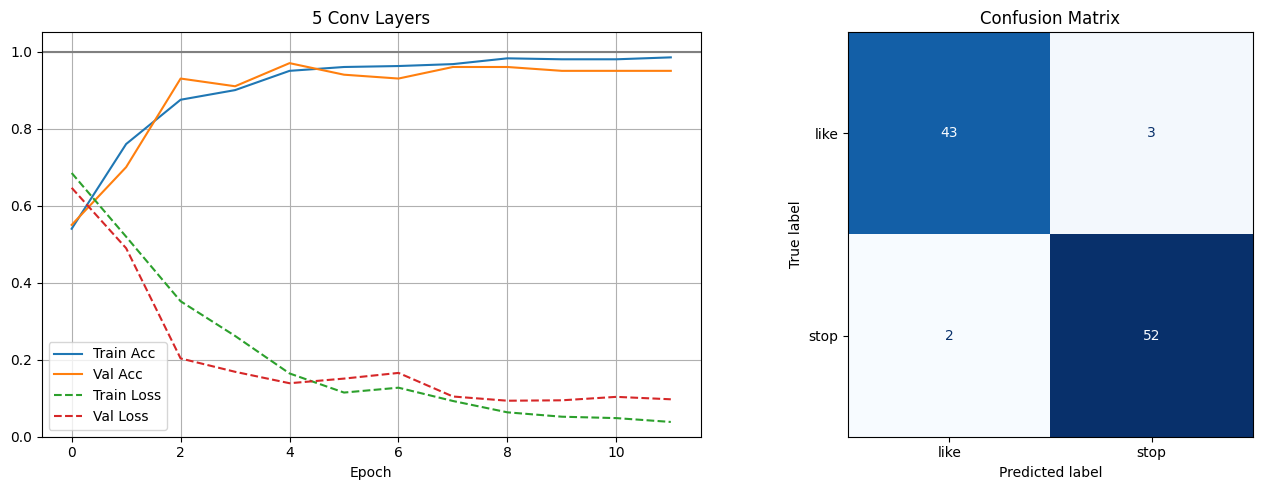

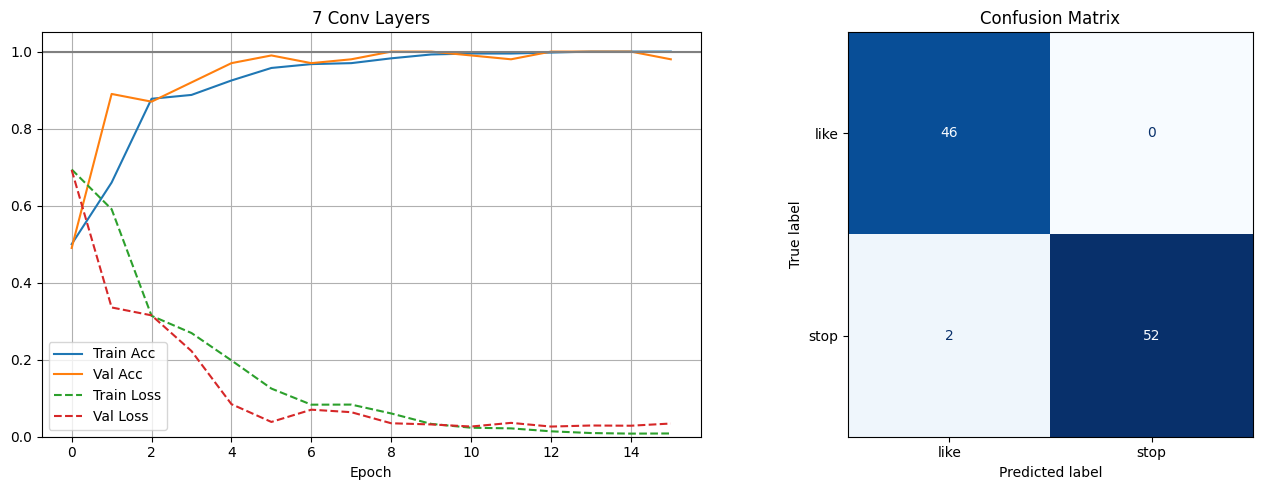

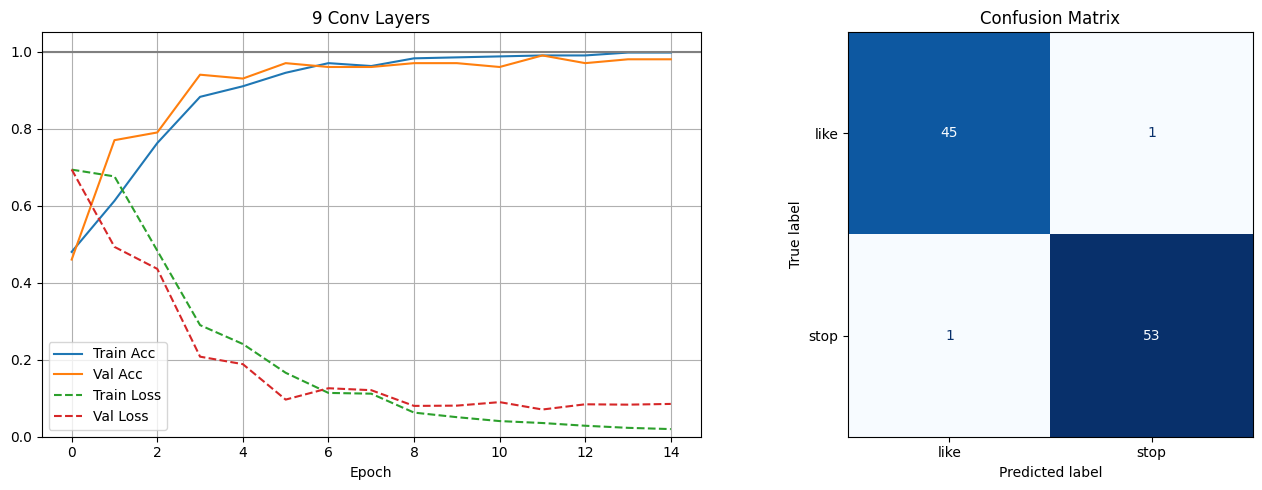

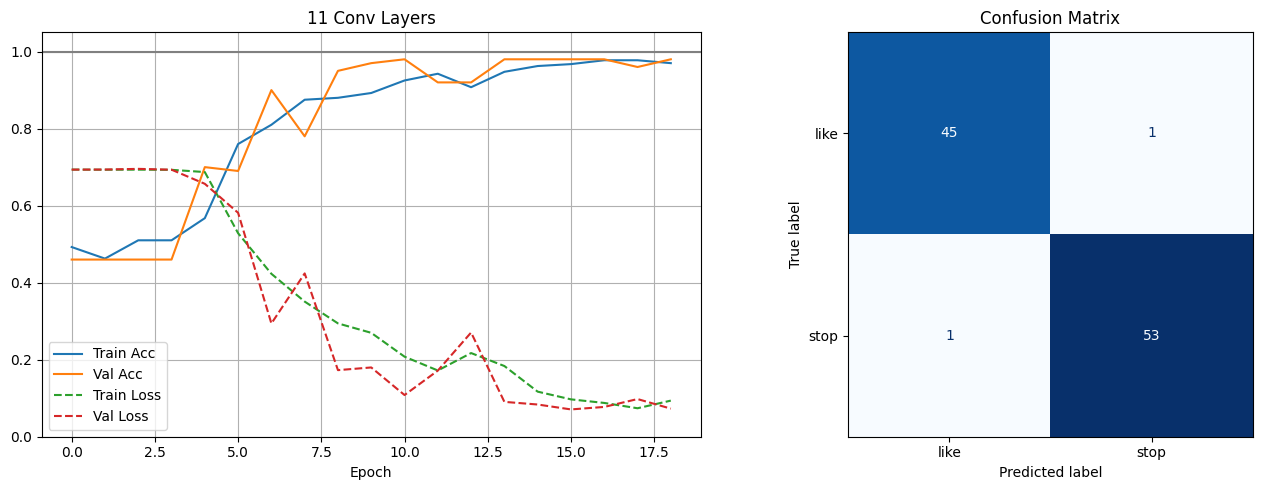

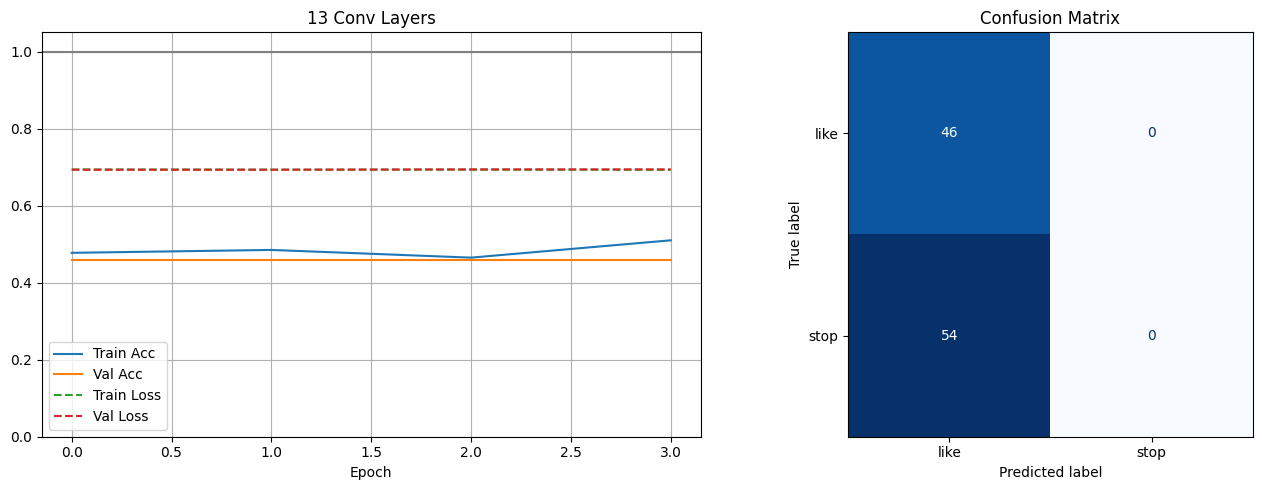

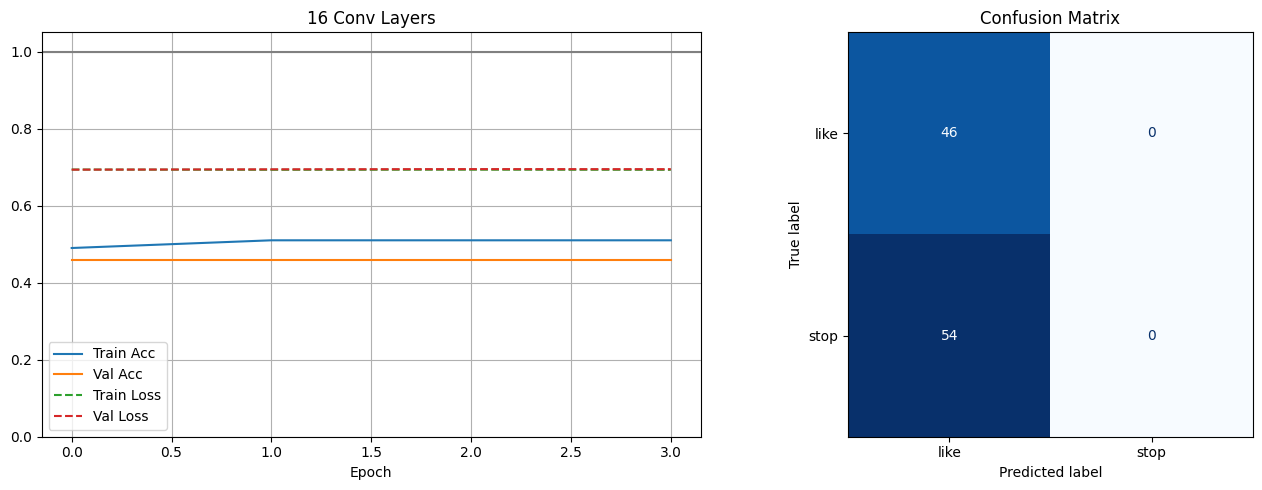

In [136]:
#Plot trainings-process and the according confusion-Matrix
for i, his in enumerate(histories):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy/Loss Plot
    ax1.plot(his.history['accuracy'], label='Train Acc')
    ax1.plot(his.history['val_accuracy'], label='Val Acc')
    ax1.plot(his.history['loss'], '--', label='Train Loss')
    ax1.plot(his.history['val_loss'], '--', label='Val Loss')
    
    ax1.set_ylim(0, 1.05)
    ax1.axhline(1, color='gray')
    ax1.set_title(f"{conv_layer_counts[i]} Conv Layers")
    ax1.set_xlabel("Epoch")
    ax1.legend()
    ax1.grid(True)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrices[i],display_labels=label_names)
    disp.plot(ax=ax2, cmap="Blues", colorbar=False)
    ax2.set_title("Confusion Matrix")

    plt.tight_layout()
    plt.show()


## Results

I choose the standard values for Filtersize, Kernelsize, Poolingsize (32, (3,3), (2,2) for the test. I didn't change them with each iteration since the only independed variable is the number of layers.
Every other value was kept the same in the hope the others also didn't change anything, so results are better comparable. The other layers were kept to keep a standard training pipeline and to get useful results

It shows that adding more convolutional layers first improves the accuracy up to a certain point, where both accuracys go towards 1.0  and then doesn't really change (between 0.95-0.98, val-accuracy mostly reaches it's peak at 4 layers). After a certain depth (sometimes 11, othertimes 13 layers), the performance drops strongly for both accuracies and stays the exact same onwards (practically saying it just guesses 1/classes propability). That should also be related to the 64x64 images and could be different with bigger sizes.
The needed Epochs also tend to get less with more layers (changes with every run, but mostly) and from arround 12/13 they become much less (the performance of the models stays consistently bad here (because of output-shape from pooling)

I also tried without pooling and it already dropped accuracy at 9 Layers, fitting took MUCH longer and was generally alot less stable. Accuracies overall were lower too. Overall the endresult were pretty similar though

Following the Model-Summaries:

In [103]:
for i, mod in enumerate(models):
    mod.summary()
    print(f"\033[1m    Val-Accuracy: {val_accs[i]:.2f}%\033[0m")
    print(f"\033[1m    Accuracy: {train_accs[i]:.2f}%\033[0m")
    print(f"\033[1m    Epochs: {epochs_used[i]}\033[0m")

    

Model: "Model-0-Layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout_319 (Dropout)                │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_319 (Flatten)                │ (None, 12288)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_811 (Dense)                    │ (None, 64)                  │         786,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_812 (Dense)                    │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,359,880 (9.00 MB)

 Trainable params: 786,626 (3.00 MB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 425,576 (1.62 MB)

 Trainable params: 141,858 (554.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 283,718 (1.08 MB)

    Val-Accuracy: 0.46%
    Accuracy: 0.51%
    Epochs: 5


## Param-Comparison

Trainable Parameters
layers 0 : 786,626
layers 1 : 2,098,242
layers 2 : 534,626
layers 3 : 150,658
layers 4 : 61,602
layers 5 : 46,274 
layers 7 : 58,626
layers 9 : 77,122
layers 11: 95,618
layers 13: 114,114
layers 16: 141,858

The Trainable Parameters get less with the more sensible layer count, reaching the lowest at 7layers, where the output dimension reaches 1x1.
It also shows the problem with the dimesion, leading to worse results the more layers one adds

# -------------------END-----------------------------
Following original code:

In [ ]:
# variables for hyperparameters
batch_size = 8
epochs = 50
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'  # LeakyReLU
layer_count = 2
num_neurons = 64

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
model = Sequential()

# data augmentation (this can also be done beforehand - but don't augment the test dataset!)
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))
#model.add(RandomBrightness(0.1))
#model.add(RandomRotation(0.2))

# first, we add some convolution layers followed by max pooling
model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

# dropout layers can drop part of the data during each epoch - this prevents overfitting
model.add(Dropout(0.2))

# after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
model.add(Flatten())

# add some fully connected layers ("Dense")
for i in range(layer_count - 1):
    model.add(Dense(num_neurons, activation=activation))

model.add(Dense(num_neurons, activation=activation))

# for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
model.add(Dense(num_classes, activation='softmax'))

# specify loss function, optimizer and evaluation metrics
# for classification, categorial crossentropy is used as a loss function
# use the adam optimizer unless you have a good reason not to
model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

## now, we can train the model using the fit() function
## this will take a while

In [ ]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

In [ ]:
# let's have a look at our model
model.summary()

## Plot accuracy and loss of the training process

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

## saving the model

the function will create a directory for your model and save structure and weights in there

sometimes you will see the .h5 format being used - even though this is a bit faster and needs less space, it comes with its limitations and isn't used that much any more

In [ ]:
if not os.path.exists("models"):
    os.mkdir("models")
model.save('models/gesture_recognition')

# and this is how you load the model
# model = keras.models.load_model("gesture_recognition")

## visualize classification results with a confusion matrix

In [ ]:
# let the model make predictions for our training data
y_predictions = model.predict(X_test)

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass

## let's test our model in action

In [ ]:
cap = cv2.VideoCapture(0)
ret, frame = cap.read()
if COLOR_CHANNELS == 1:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
cap.release()
plt.imshow(frame)

## manual cropping for demonstration purposes - you can do better!

In [ ]:
plt.imshow(frame[50:350, 60:210])

In [ ]:
resized = cv2.resize(frame[50:350, 60:210], SIZE)#[20:350, 200:420], SIZE)
plt.imshow(resized)
resized.shape

In [ ]:
reshaped = resized.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
reshaped.shape
prediction = model.predict(reshaped)

print(label_names[np.argmax(prediction)], np.max(prediction))

In [ ]:
filters, biases = model.layers[2].get_weights()
print(filters.shape)

fig, axes = plt.subplots(8, 8, figsize=(20, 20))

for i in range(8):
    for j in range(8):
        img = filters[:,:,:,i*8+j]
        axes[i][j].imshow(img)

In [ ]:
fig, axes = plt.subplots(8, 8, figsize=(20, 20))

for i in range(8):
    for j in range(8):
        #axes[i][j].imshow(filters[:,:,:,i*8+j] * 255, 'gray')
        kernel = filters[:,:,0,i*8+j]

        #print(kernel.shape)

        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
        filtered = cv2.filter2D(gray, -1, kernel)

        axes[i][j].imshow(filtered, 'gray')

## Transfer Learning

let's use a pre-trained model (VGG16) for our prediction

note that VGG16 needs three color channels

In [ ]:
batch_size = 8
epochs = 50
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'LeakyReLU'  # LeakyReLU
layer_count = 2
num_neurons = 256

# load a VGG16 model trained on the imagenet dataset
# include_top=False -> do not include the output layer
# input_tensor -> tells the model about the dimensions of our images (VGG16 needs three color channels)
# pooling -> which type of pooling to use between convolutions; max or avg seem to be the best
VGG = VGG16(weights='imagenet', include_top=False, input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)), pooling='max')

# we want to use the VGG's original weights -> make those layers untrainable
for layer in VGG.layers:
    layer.trainable = False

# build a new model and add the VGG layers
model_vgg = Sequential()
model_vgg.add(VGG)

# append dense layers at the end
for i in range(layer_count - 1):
    model_vgg.add(Dense(num_neurons, activation=activation))
model_vgg.add(Dropout(0.2))

model_vgg.add(Dense(num_neurons, activation=activation))

# classifier
model_vgg.add(Dense(num_classes, activation='softmax'))

model_vgg.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

In [ ]:
history_vgg = model_vgg.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

In [ ]:
model_vgg.summary()

In [ ]:
loss = history_vgg.history['loss']
val_loss = history_vgg.history['val_loss']
accuracy = history_vgg.history['accuracy']
val_accuracy = history_vgg.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

In [ ]:
# let the model make predictions for our training data
y_predictions = model_vgg.predict(X_test)

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass